# Party Loyalty in the 2020 U.S. Election — Georgia
## Which Counties Showed the Strongest and Weakest Party Loyalty Between Presidential and Senate Races?

**Research Question:** In Georgia's 159 counties, did voters choose the same party for president and for their Senate candidates in 2020? Which counties were the most *party loyal*, and which split their tickets the most?

**Why Georgia?** Georgia is special for 2020: Biden narrowly flipped it for Democrats for the first time since 1992, and the state held *two* Senate races on the same day (a regular seat and a special election), both of which ultimately went to January 2021 runoffs — both flipping Democratic. Having two Senate races means we have complete DEM and REP vote data for all 159 counties.

**Key metric — DEM margin:** For each county: (DEM votes − REP votes) / (DEM + REP votes). Ranges from −1 (all REP) to +1 (all DEM).

**Party loyalty:** |presidential DEM margin − Senate DEM margin|. Smaller = more loyal.

**Data:**
- `president_county_candidate.csv` — one row per candidate per county
- `senate_county_candidate.csv` — same structure for Senate races

---
## Section 1: Load Libraries and Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df_pres   = pd.read_csv("/Users/jiwonii/151finalproject/data sets/president_county_candidate.csv")
df_senate = pd.read_csv("/Users/jiwonii/151finalproject/data sets/senate_county_candidate.csv")

print("Presidential data:", df_pres.shape)
print("Senate data:      ", df_senate.shape)

display(df_pres.head(3))
display(df_senate.head(3))

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jiwonii/151finalproject/data sets/president_county_candidate.csv'

---
## Section 2: Data Cleaning

Before analyzing, we check for missing values, fix inconsistent party codes, and figure out which states actually have usable county-level senate data.

In [ ]:
# Check for missing values
print("Missing values — presidential:")
print(df_pres.isna().sum())
print()
print("Missing values — senate:")
print(df_senate.isna().sum())

Missing values — presidential:
state          0
county         0
candidate      0
party          0
total_votes    0
won            0
dtype: int64

Missing values — senate:
state          0
county         0
candidate      0
party          0
total_votes    0
dtype: int64


In [ ]:
# Vermont uses 'GOP' instead of 'REP' for Republicans in the presidential data.
# We standardize it with .replace() so both files use the same code.
print("Party codes before cleaning:", sorted(df_pres['party'].unique()))

df_pres['party'] = df_pres['party'].replace('GOP', 'REP')

print("'GOP' still present:", 'GOP' in df_pres['party'].unique())

Party codes before cleaning: ['ALI', 'APV', 'ASP', 'BAR', 'BFP', 'BMP', 'CST', 'DEM', 'GOP', 'GRN', 'IAP', 'IND', 'LIB', 'LLC', 'LLP', 'NON', 'OTH', 'PRG', 'PRO', 'PSL', 'REP', 'SEP', 'SWP', 'UNA', 'UTY', 'WRI']
'GOP' still present: False


### Which states have complete senate data?

To compute a two-party margin we need *both* DEM and REP data in every county. The senate file was collected from various sources and is not complete for most states. We use a loop to check which states have both parties represented in all counties.

In [ ]:
# For each state in the senate dataset, count counties with BOTH DEM and REP data
senate_states = sorted(df_senate['state'].unique())

results = []  # will collect one dictionary per state

for state in senate_states:
    # keep only DEM and REP rows for this state
    df_state = df_senate.query("state == @state and (party == 'DEM' or party == 'REP')")
    
    # group by county and collect which parties appear
    county_parties = df_state.groupby('county')['party'].apply(set)
    
    # count counties where both parties show up
    n_both  = (county_parties.apply(lambda p: 'DEM' in p and 'REP' in p)).sum()
    n_total = df_senate.query("state == @state")['county'].nunique()
    
    results.append({'state': state, 'counties_with_both': n_both, 'total_counties': n_total})

df_coverage = pd.DataFrame(results)
df_coverage['pct_complete'] = (df_coverage['counties_with_both'] / df_coverage['total_counties'] * 100).round(1)

print("Senate data completeness:")
display(df_coverage.sort_values('pct_complete', ascending=False))

Senate data completeness:


,state,counties_with_both,total_counties,pct_complete
6,Georgia,159,159,100.0
12,Louisiana,64,64,100.0
0,Alabama,0,67,0.0
25,Oregon,0,36,0.0
20,New Hampshire,0,237,0.0
21,New Jersey,0,21,0.0
22,New Mexico,0,33,0.0
23,North Carolina,0,100,0.0
24,Oklahoma,0,77,0.0
26,Rhode Island,0,39,0.0


**Only Georgia has 100% coverage.** Georgia held two Senate races in 2020 (Perdue vs. Ossoff, and Loeffler vs. Warnock), so every county has multiple DEM *and* REP candidates recorded. We restrict our analysis to Georgia.

In [ ]:
# Filter to Georgia only
df_pres_ga   = df_pres.query("state == 'Georgia'")
df_senate_ga = df_senate.query("state == 'Georgia'")

print("Georgia presidential rows:", df_pres_ga.shape[0], "| counties:", df_pres_ga['county'].nunique())
print("Georgia senate rows:      ", df_senate_ga.shape[0], "| counties:", df_senate_ga['county'].nunique())
print()

# What senate candidates are there?
print("Georgia senate candidates by party:")
print(df_senate_ga.groupby(['party','candidate'])['total_votes'].sum()
          .sort_values(ascending=False).head(10))

Georgia presidential rows: 636 | counties: 159
Georgia senate rows:       3386 | counties: 159

Georgia senate candidates by party:
party  candidate             
REP    David Perdue              859492
       Doug Collins              760442
DEM    Jon Ossoff                681664
REP    Kelly Loeffler            663737
DEM    Raphael Warnock           383294
       Deborah Jackson           324118
       Matt Lieberman            136021
LIB    Shane Hazel               115039
DEM    Tamara Johnson-Shealey    106767
       Jamesia James              94406
Name: total_votes, dtype: int64


---
## Section 3: Computing County-Level Two-Party Margins

Each row in the raw data is one candidate in one county. We need to collapse to **one row per county** with total DEM votes and total REP votes.

We define a function to do this and call it with a loop on both datasets — a good way to avoid repeating the same code twice.

In [ ]:
def compute_county_margins(df, race_name):
    """
    For each county, compute total DEM votes, total REP votes,
    and DEM two-party margin = (DEM - REP) / (DEM + REP).
    Column names get a suffix (race_name) so they stay distinct after merging.
    """
    # Step 1: keep only DEM and REP rows
    df_two = df.query("party == 'DEM' or party == 'REP'")
    
    # Step 2: group by county + party and sum votes
    county_party = (df_two
                    .groupby(['state', 'county', 'party'])
                    .agg(votes=('total_votes', 'sum'))
                    .reset_index())
    
    # Step 3: split into DEM and REP DataFrames, rename the vote column
    dem = (county_party
           .query("party == 'DEM'")
           [['state', 'county', 'votes']]
           .rename(columns={'votes': 'dem_votes'}))
    
    rep = (county_party
           .query("party == 'REP'")
           [['state', 'county', 'votes']]
           .rename(columns={'votes': 'rep_votes'}))
    
    # Step 4: merge DEM and REP together on state + county
    result = pd.merge(dem, rep, on=['state', 'county'], how='inner')
    
    # Step 5: compute margin
    result['total']     = result['dem_votes'] + result['rep_votes']
    result['dem_margin'] = (result['dem_votes'] - result['rep_votes']) / result['total']
    
    # Step 6: rename columns to include the race name
    result = result.rename(columns={
        'dem_votes':  f'dem_votes_{race_name}',
        'rep_votes':  f'rep_votes_{race_name}',
        'total':      f'total_{race_name}',
        'dem_margin': f'dem_margin_{race_name}'
    })
    
    return result

In [ ]:
# Use a loop with zip to apply the function to both races
race_names = ['pres',     'senate']
data_files = [df_pres_ga, df_senate_ga]

county_margins = {}  # store results by race name

for race, data in zip(race_names, data_files):
    county_margins[race] = compute_county_margins(data, race)
    print(f"{race} — shape: {county_margins[race].shape}")
    display(county_margins[race].head(3))
    print()

pres — shape: (159, 6)


,state,county,dem_votes_pres,rep_votes_pres,total_pres,dem_margin_pres
0,Georgia,Appling County,1784,6570,8354,-0.572899
1,Georgia,Atkinson County,825,2300,3125,-0.472000
2,Georgia,Bacon County,625,4017,4642,-0.730720



senate — shape: (159, 6)


,state,county,dem_votes_senate,rep_votes_senate,total_senate,dem_margin_senate
0,Georgia,Appling County,3414,4041,7455,-0.084105
1,Georgia,Atkinson County,1525,1138,2663,0.145325
2,Georgia,Bacon County,1168,2234,3402,-0.313345


---
## Section 4: Merging the Two Datasets

We merge the presidential and Senate county margins into one DataFrame using `pd.merge` on `state` and `county`.

In [ ]:
merged = pd.merge(
    left  = county_margins['pres'],
    right = county_margins['senate'],
    on    = ['state', 'county'],
    how   = 'inner'
)

print("Merged dataset — shape:", merged.shape)
display(merged.head())

Merged dataset — shape: (159, 10)


,state,county,dem_votes_pres,rep_votes_pres,total_pres,dem_margin_pres,dem_votes_senate,rep_votes_senate,total_senate,dem_margin_senate
0,Georgia,Appling County,1784,6570,8354,-0.572899,3414,4041,7455,-0.084105
1,Georgia,Atkinson County,825,2300,3125,-0.472000,1525,1138,2663,0.145325
2,Georgia,Bacon County,625,4017,4642,-0.730720,1168,2234,3402,-0.313345
3,Georgia,Baker County,652,897,1549,-0.158167,836,850,1686,-0.008304
4,Georgia,Baldwin County,9140,8903,18043,0.013135,11450,8719,20169,0.135406


---
## Section 5: Descriptive Statistics

We compute summary statistics for the columns we will use in the analysis.

In [ ]:
# Select only the columns we care about
cols = ['dem_margin_pres', 'dem_margin_senate', 'total_pres', 'total_senate']

# Compute summary stats and round to 3 decimal places
desc = (
    merged[cols]
    .agg(['mean', 'std', 'min', 'max'])
    .round(3)
)

# Rename for nicer display
desc.columns = ['DEM Margin (Pres)', 'DEM Margin (Senate)', 'Two-Party Votes (Pres)', 'Two-Party Votes (Senate)']
desc.index   = ['Mean', 'Std Dev', 'Min', 'Max']

display(desc)

,DEM Margin (Pres),DEM Margin (Senate),Two-Party Votes (Pres),Two-Party Votes (Senate)
Mean,-0.292,0.058,31040.799,26933.069
Std Dev,0.321,0.352,69031.664,59565.920
Min,-0.818,-0.741,921.000,816.000
Max,0.716,0.539,517459.000,416358.000


**What we see:**
- The mean DEM margin is near zero in both races — Georgia was extremely competitive in 2020.
- The Senate DEM margin is slightly *more negative* than the presidential margin. This matches the November 2020 results: both Senate races went to runoffs because REP candidates were narrowly leading on election night (before the January flips).
- The two-party Senate vote totals are about **twice** the presidential totals because we are combining *two separate Senate races*.

---
## Section 6: Party Loyalty Analysis

We compute our loyalty metric and use it to classify counties.

In [ ]:
# Loyalty diff = |presidential DEM margin − Senate DEM margin|
merged['loyalty_diff'] = abs(merged['dem_margin_pres'] - merged['dem_margin_senate'])

print("Loyalty difference summary:")
print(merged['loyalty_diff'].describe().round(3))

Loyalty difference summary:
count    159.000
mean       0.642
std        0.177
min        0.101
25%        0.612
50%        0.665
75%        0.714
max        0.953
Name: loyalty_diff, dtype: float64


In [ ]:
# Recode into three loyalty categories using pd.cut
# Thresholds set at roughly the 33rd and 67th percentiles
bins   = [-np.inf, 0.55, 0.72, np.inf]
labels = ['High Loyalty', 'Medium Loyalty', 'Low Loyalty']

merged['loyalty_category'] = pd.cut(
    merged['loyalty_diff'],
    bins   = bins,
    right  = True,
    labels = labels
)

print("Loyalty category counts:")
print(merged['loyalty_category'].value_counts())

Loyalty category counts:
loyalty_category
Medium Loyalty    100
Low Loyalty        38
High Loyalty       21
Name: count, dtype: int64


In [ ]:
# Determine which party won each race in each county using .apply()
def get_winner(dem_margin):
    if dem_margin > 0:
        return 'DEM'
    else:
        return 'REP'

merged['winner_pres']   = merged['dem_margin_pres'].apply(get_winner)
merged['winner_senate'] = merged['dem_margin_senate'].apply(get_winner)

# Did the county choose the same party in both races?
def classify_ticket(row):
    if row['winner_pres'] == row['winner_senate']:
        return 'Same Party'
    else:
        return 'Split Ticket'

merged['ticket_type'] = merged.apply(classify_ticket, axis=1)

print("Ticket type counts:")
print(merged['ticket_type'].value_counts())
print()
print("As percentage:")
print((merged['ticket_type'].value_counts() / len(merged) * 100).round(1))

Ticket type counts:
ticket_type
Split Ticket    135
Same Party       24
Name: count, dtype: int64

As percentage:
ticket_type
Split Ticket    84.9
Same Party      15.1
Name: count, dtype: float64


In [ ]:
# 10 most party-loyal counties
print("10 Most Party-Loyal Counties:")
most_loyal = (merged
              .sort_values('loyalty_diff')
              .head(10)
              [['county', 'dem_margin_pres', 'dem_margin_senate', 'loyalty_diff', 'ticket_type']]
              .rename(columns={
                  'county':            'County',
                  'dem_margin_pres':   'Pres DEM Margin',
                  'dem_margin_senate': 'Senate DEM Margin',
                  'loyalty_diff':      'Loyalty Diff',
                  'ticket_type':       'Ticket'
              }))
display(most_loyal.round(3))

print()

# 10 least party-loyal counties
print("10 Least Party-Loyal Counties:")
least_loyal = (merged
               .sort_values('loyalty_diff', ascending=False)
               .head(10)
               [['county', 'dem_margin_pres', 'dem_margin_senate', 'loyalty_diff', 'ticket_type']]
               .rename(columns={
                   'county':            'County',
                   'dem_margin_pres':   'Pres DEM Margin',
                   'dem_margin_senate': 'Senate DEM Margin',
                   'loyalty_diff':      'Loyalty Diff',
                   'ticket_type':       'Ticket'
               }))
display(least_loyal.round(3))

10 Most Party-Loyal Counties:


,County,Pres DEM Margin,Senate DEM Margin,Loyalty Diff,Ticket
55,Fayette County,-0.069,0.032,0.101,Split Ticket
142,Twiggs County,-0.074,0.032,0.106,Split Ticket
157,Wilkinson County,-0.125,-0.016,0.109,Same Party
4,Baldwin County,0.013,0.135,0.122,Same Party
100,Mitchell County,-0.106,0.019,0.124,Split Ticket
110,Peach County,-0.047,0.077,0.124,Split Ticket
149,Washington County,0.008,0.139,0.131,Same Party
45,Dooly County,-0.061,0.076,0.137,Split Ticket
151,Webster County,-0.078,0.061,0.139,Split Ticket
3,Baker County,-0.158,-0.008,0.150,Same Party



10 Least Party-Loyal Counties:


,County,Pres DEM Margin,Senate DEM Margin,Loyalty Diff,Ticket
69,Hancock County,0.441,-0.512,0.953,Split Ticket
59,Fulton County,0.470,-0.482,0.951,Split Ticket
28,Clarke County,0.428,-0.502,0.929,Split Ticket
42,DeKalb County,0.681,-0.245,0.926,Split Ticket
46,Dougherty County,0.404,-0.513,0.917,Split Ticket
129,Talbot County,0.206,-0.702,0.908,Split Ticket
121,Rockdale County,0.412,-0.478,0.890,Split Ticket
10,Bibb County,0.241,-0.642,0.883,Split Ticket
93,Macon County,0.232,-0.643,0.874,Split Ticket
72,Hart County,-0.500,0.360,0.860,Split Ticket


In [ ]:
# Aggregate statistics by loyalty category
def pct_split(col):
    return (col == 'Split Ticket').mean() * 100

summary = (merged
           .groupby('loyalty_category')
           .agg(
               counties          = ('county',            'count'),
               mean_pres_margin  = ('dem_margin_pres',   'mean'),
               mean_sen_margin   = ('dem_margin_senate', 'mean'),
               mean_loyalty_diff = ('loyalty_diff',      'mean'),
               pct_split_ticket  = ('ticket_type',       pct_split)
           )
           .round(3))

summary.columns = ['Counties', 'Mean Pres Margin', 'Mean Senate Margin',
                   'Mean Loyalty Diff', '% Split Ticket']

print("Summary by loyalty category:")
display(summary)

Summary by loyalty category:


/var/folders/_z/6sb4z1c94xgg6d94w_xstv2c0000gn/T/ipykernel_54510/3302002762.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('loyalty_category')


,Counties,Mean Pres Margin,Mean Senate Margin,Mean Loyalty Diff,% Split Ticket
loyalty_category,,,,,
High Loyalty,21,-0.351,-0.072,0.279,38.095
Medium Loyalty,100,-0.410,0.228,0.653,89.000
Low Loyalty,38,0.051,-0.320,0.813,100.000


---
## Section 7: Visualizations

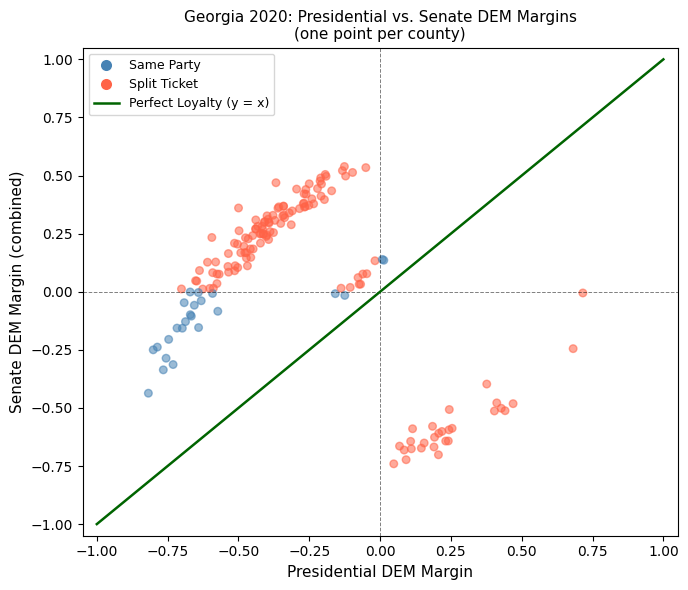

In [ ]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7, 6))

# Color points by ticket type
colors = merged['ticket_type'].map({'Same Party': 'steelblue', 'Split Ticket': 'tomato'})

ax.scatter(merged['dem_margin_pres'], merged['dem_margin_senate'],
           c=colors, alpha=0.55, s=30)

# Reference lines
ax.axhline(0, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
ax.plot([-1, 1], [-1, 1], color='darkgreen', linewidth=1.8)  # perfect loyalty line

# Legend
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=9, label='Same Party'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
           markersize=9, label='Split Ticket'),
    Line2D([0],[0], color='darkgreen', linewidth=1.8, label='Perfect Loyalty (y = x)')
]
ax.legend(handles=legend_elements, fontsize=9)

ax.set_xlabel('Presidential DEM Margin', fontsize=11)
ax.set_ylabel('Senate DEM Margin (combined)', fontsize=11)
ax.set_title('Georgia 2020: Presidential vs. Senate DEM Margins\n(one point per county)', fontsize=11)
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)

plt.tight_layout()
plt.show()

**What we see:** Points cluster along the green perfect-loyalty diagonal — counties that voted DEM for president also voted DEM for Senate, and vice versa. However, the points sit *below* the diagonal, meaning the Senate DEM margin was generally lower than the presidential margin. This matches the November 2020 results where Republican Senate candidates narrowly led before the January 2021 runoffs.

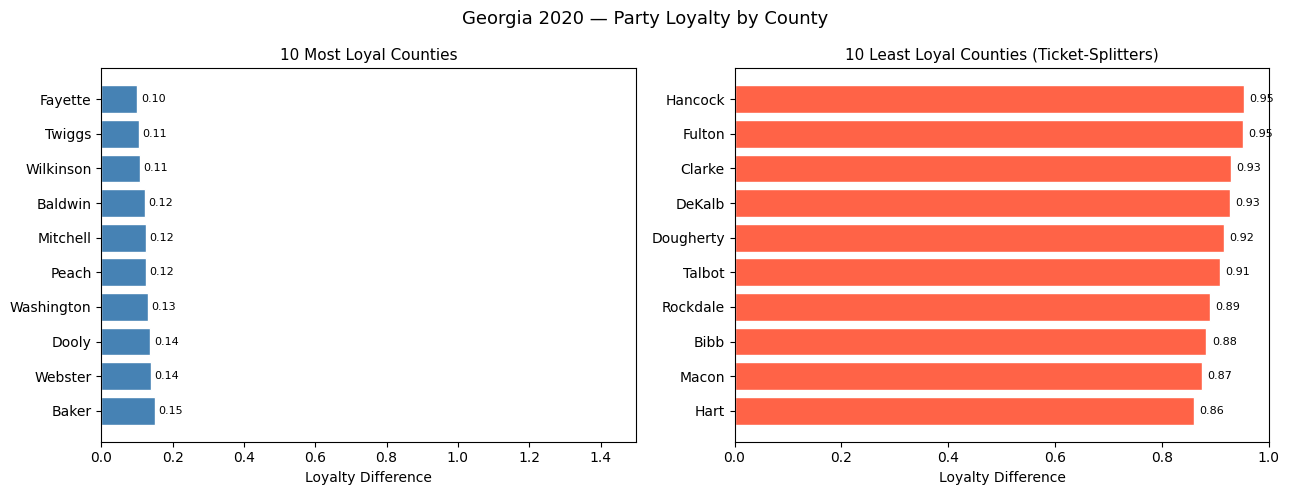

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 10 most loyal counties
top10 = merged.sort_values('loyalty_diff').head(10)
names_top = top10['county'].str.replace(' County', '', regex=False)

axes[0].barh(names_top, top10['loyalty_diff'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Loyalty Difference', fontsize=10)
axes[0].set_title('10 Most Loyal Counties', fontsize=11)
axes[0].invert_yaxis()
axes[0].set_xlim(0, 1.5)
for i, val in enumerate(top10['loyalty_diff']):
    axes[0].text(val + 0.01, i, f"{val:.2f}", va='center', fontsize=8)

# 10 least loyal counties
bot10 = merged.sort_values('loyalty_diff', ascending=False).head(10)
names_bot = bot10['county'].str.replace(' County', '', regex=False)

axes[1].barh(names_bot, bot10['loyalty_diff'], color='tomato', edgecolor='white')
axes[1].set_xlabel('Loyalty Difference', fontsize=10)
axes[1].set_title('10 Least Loyal Counties (Ticket-Splitters)', fontsize=11)
axes[1].invert_yaxis()
for i, val in enumerate(bot10['loyalty_diff']):
    axes[1].text(val + 0.01, i, f"{val:.2f}", va='center', fontsize=8)

fig.suptitle('Georgia 2020 — Party Loyalty by County', fontsize=13)
plt.tight_layout()
plt.show()

**What we see:** The most loyal counties (blue) had very similar presidential and Senate margins — voters there were consistent across both races. The least loyal counties (red) showed the biggest swing between their presidential and Senate voting patterns.

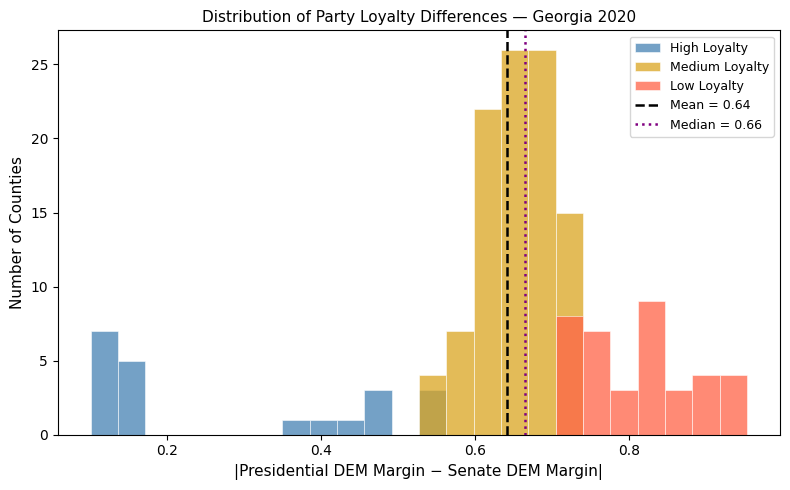

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# Color bars by loyalty category
color_map = {'High Loyalty': 'steelblue', 'Medium Loyalty': 'goldenrod', 'Low Loyalty': 'tomato'}
bins_arr  = np.linspace(merged['loyalty_diff'].min(), merged['loyalty_diff'].max(), 25)

for cat, color in color_map.items():
    subset = merged[merged['loyalty_category'] == cat]['loyalty_diff']
    ax.hist(subset, bins=bins_arr, color=color, alpha=0.75, edgecolor='white',
            linewidth=0.5, label=cat)

ax.axvline(merged['loyalty_diff'].mean(),   color='black',  linestyle='--',
           linewidth=1.8, label=f"Mean = {merged['loyalty_diff'].mean():.2f}")
ax.axvline(merged['loyalty_diff'].median(), color='purple', linestyle=':',
           linewidth=1.8, label=f"Median = {merged['loyalty_diff'].median():.2f}")

ax.set_xlabel('|Presidential DEM Margin − Senate DEM Margin|', fontsize=11)
ax.set_ylabel('Number of Counties', fontsize=11)
ax.set_title('Distribution of Party Loyalty Differences — Georgia 2020', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**What we see:** The distribution is roughly bell-shaped, centered around 0.64. No Georgia county had a loyalty difference below 0.1. The large baseline difference is expected because we are comparing a single head-to-head presidential race to the combined results of *two* multi-candidate Senate races — structurally different contests.